# Modelos ampliados y alertas — copia de 05_2

Se conserva la referencia 05_2 en las secciones 1–9 y se añade el bloque 10:
variables causales de PM2.5, LightGBM, clasificadores y horizontes de 6/12/24 h,
además de cualquier superación dentro de las próximas 24 h.

**Dependencia adicional:** LightGBM. Si no está instalado, ejecutar `%pip install lightgbm`
en una celda y reiniciar el kernel antes de ejecutar todo.

CSV de referencia: `data/processed/beijing_data_huecos_24h.csv`.
CSV del bloque nuevo: `data/processed/beijing_data_preparado.csv`, con variables
realineadas para cada horizonte. No reutilizar los desplazamientos de 24 h para 6 h.

La evaluación de 2014 es reutilizada, no un test nuevo nunca visto.



In [2]:
# Comprobar dependencias antes de entrenar la referencia.
from lightgbm import LGBMRegressor, LGBMClassifier
from pathlib import Path
from time import perf_counter
from threadpoolctl import threadpool_limits

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from skforecast.recursive import ForecasterRecursive

INICIO = perf_counter()
EJECUTAR_PICOS = False
H = 24
UMBRAL = 150
SEMILLA = 42
RAIZ = Path('..') if Path('../data').exists() else Path('.')
print('skforecast:', __import__('skforecast').__version__)


skforecast: 0.25.0


c:\Users\martin\Documents\uc3m - Applied AI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="The 'generic' unit for NumPy timedelta is deprecated.*",
    category=DeprecationWarning
)

## 1. Datos

Se lee `beijing_data_huecos_24h.csv`, con PM2.5, calendario y meteorología desplazada 24 horas.
Se conserva el calendario horario. El CSV auxiliar preparado permite identificar los objetivos
imputados y excluirlos de las métricas y del entrenamiento mediante pesos.


In [4]:
df = pd.read_csv(RAIZ / 'data/processed/beijing_data_huecos_24h.csv',
                 index_col='datetime', parse_dates=True)
df = df.sort_index().asfreq('h')

print('Horas:', len(df))
print('Huecos en PM2.5:', df['pm2.5'].isna().sum())
df.head()

Horas: 43752
Huecos en PM2.5: 1463


,pm2.5,cal_sen_hora,cal_cos_hora,cal_sen_dia,cal_cos_dia,cal_sen_mes,cal_cos_mes,DEWP_obs_24,TEMP_obs_24,PRES_obs_24,...,viento_SE_obs_24,TEMP_trend_24_30,TEMP_trend_24_36,TEMP_trend_24_48,PRES_trend_24_30,PRES_trend_24_36,PRES_trend_24_48,DEWP_trend_24_30,DEWP_trend_24_36,DEWP_trend_24_48
datetime,,,,,,,,,,,,,,,,,,,,,
2010-01-04 00:00:00,79.0,0.000000,1.000000,0.0,1.0,0.0,1.0,-7.0,-6.0,1027.0,...,1,-1.0,-1.0,-2.0,0.0,1.0,7.0,1.0,1.0,9.0
2010-01-04 01:00:00,58.0,0.258819,0.965926,0.0,1.0,0.0,1.0,-8.0,-6.0,1026.0,...,1,-1.0,-1.0,-2.0,-2.0,1.0,6.0,0.0,0.0,7.0
2010-01-04 02:00:00,25.0,0.500000,0.866025,0.0,1.0,0.0,1.0,-8.0,-7.0,1026.0,...,1,-2.0,-2.0,-2.0,-2.0,1.0,5.0,-1.0,1.0,3.0
2010-01-04 03:00:00,26.0,0.707107,0.707107,0.0,1.0,0.0,1.0,-8.0,-7.0,1025.0,...,1,-2.0,-2.0,-2.0,-2.0,0.0,3.0,-1.0,1.0,-1.0
2010-01-04 04:00:00,28.0,0.866025,0.500000,0.0,1.0,0.0,1.0,-8.0,-7.0,1024.0,...,1,-1.0,-2.0,-2.0,-4.0,-2.0,2.0,0.0,1.0,-1.0


## 2. Variables predictoras

Las exógenas están alineadas con la hora objetivo: el calendario es conocido y la
meteorología está desplazada 24 horas. `ForecasterRecursive` construye los lags.
Como todos son mayores o iguales al horizonte, el paso 24 solo depende del historial
observado hasta el origen. Se predice ese paso por lotes con el estimador entrenado.
La marca de imputación solo controla los pesos, no se usa como predictor.


In [5]:
# Skforecast recibe la serie completa y construye los retardos internamente.
# La marca se recupera del CSV preparado, que es el único que la conserva.
df_trazabilidad = pd.read_csv(
    RAIZ / 'data/processed/beijing_data_preparado.csv',
    index_col='datetime', parse_dates=True
).sort_index().asfreq('h')

marca = df_trazabilidad['pm2.5_imputado'].reindex(df.index)
assert marca.notna().all(), 'Falta trazabilidad para algunas horas'
assert marca.isin([True, False, 0, 1]).all(), 'Marca de imputación no válida'
pm25_imputado = marca.astype(bool)

# Los huecos largos se completan solo para mantener la continuidad requerida por
# ForecasterRecursive; se marcan como imputados y no cuentan en el entrenamiento.
y_sf = df['pm2.5'].ffill()
assert y_sf.notna().all(), 'La serie empieza con huecos: recortar antes de entrenar'
pm25_imputado = pm25_imputado | df['pm2.5'].isna()
exog_sf = df.drop(columns='pm2.5').copy()

print('Observaciones para skforecast:', len(y_sf))
print('Valores imputados o completados:', int(pm25_imputado.sum()))
print('Exógenas:', exog_sf.shape[1])

assert exog_sf.notna().all().all(), 'Hay huecos en las exógenas'
assert np.isfinite(exog_sf.to_numpy()).all()


Observaciones para skforecast: 43752
Valores imputados o completados: 2043
Exógenas: 24


Los lags `[24, 25, 26, 27, 30, 36, 48]` respecto al objetivo corresponden
a la observación actual y a hace 1, 2, 3, 6, 12 y 24 horas respecto al origen.
No se añaden medias móviles. Todas las entradas están disponibles al emitir el pronóstico.
Los huecos de PM2.5 se completan hacia delante; las filas afectadas reciben peso cero.


In [6]:
# ForecasterRecursive construira estos retardos en cada fold.
lags_skforecast = [24, 25, 26, 27, 30, 36, 48]
filas_afectadas = pm25_imputado.copy()
for retardo in lags_skforecast:
    filas_afectadas = filas_afectadas | pm25_imputado.shift(retardo, fill_value=False)
print('Lags de skforecast:', lags_skforecast)
print('Ejemplos afectados por imputacion:', int(filas_afectadas.sum()))


Lags de skforecast: [24, 25, 26, 27, 30, 36, 48]
Ejemplos afectados por imputacion: 4917


## 3. Particiones temporales

Se hace uso de las mismas particiones temporales que en los modelos baseline.

Se entrena con objetivos ya observados hasta el corte. La validación empieza
con predicciones emitidas en el periodo siguiente. Por eso su primera hora
objetivo es el inicio de ese periodo más 24 horas, igual que en 05_1.

| Ronda | Entrenamiento hasta | Orígenes de validación desde | Objetivos hasta |
|---|---|---|---|
| 1 | Diciembre 2012 | Enero 2013 | Abril 2013 |
| 2 | Abril 2013 | Mayo 2013 | Agosto 2013 |
| 3 | Agosto 2013 | Septiembre 2013 | Diciembre 2013 |

El modelo se ajusta una vez por ronda. Al avanzar las horas cambian las entradas
con las nuevas observaciones disponibles, pero no se reentrena cada hora.


In [7]:
pliegues = [
    ('2012-12-31 23:00:00', '2013-01-01 00:00:00', '2013-04-30 23:00:00'),
    ('2013-04-30 23:00:00', '2013-05-01 00:00:00', '2013-08-31 23:00:00'),
    ('2013-08-31 23:00:00', '2013-09-01 00:00:00', '2013-12-31 23:00:00'),
]
for fin_train, inicio_valid, fin_valid in pliegues:
    primer_objetivo = pd.Timestamp(inicio_valid) + pd.Timedelta(hours=int(H))
    y_train_fold = y_sf.loc[:fin_train]
    indice_valid = y_sf.loc[primer_objetivo:fin_valid].index
    assert y_train_fold.index.max() < indice_valid.min() - pd.Timedelta(hours=int(H))
    print(f'Train: {len(y_train_fold)} | Validacion: {len(indice_valid)} | Primer objetivo: {indice_valid.min()}')


Train: 26232 | Validacion: 2856 | Primer objetivo: 2013-01-02 00:00:00
Train: 29112 | Validacion: 2928 | Primer objetivo: 2013-05-02 00:00:00
Train: 32064 | Validacion: 2904 | Primer objetivo: 2013-09-02 00:00:00


## 4. Métricas y validación

Se selecciona por RMSE medio en las tres rondas, como en 05_1. El MAE expresa
el error absoluto medio. El RMSE da más peso a errores grandes.
Todas las predicciones se limitan a cero como mínimo, porque una concentración
negativa no tiene sentido; se aplica la misma regla en validación y test.


In [8]:
class StandardizedRidge(RegressorMixin, BaseEstimator):
    def __init__(self, alpha=1):
        self.alpha = alpha

    def fit(self, X, y, sample_weight=None):
        self.scaler_ = StandardScaler().fit(X, sample_weight=sample_weight)
        self.model_ = Ridge(alpha=self.alpha)
        self.model_.fit(
            self.scaler_.transform(X),
            y,
            sample_weight=sample_weight
        )
        return self

    def predict(self, X):
        return self.model_.predict(self.scaler_.transform(X))

def rmse(real, predicho):
    return np.sqrt(mean_squared_error(real, predicho))

def crear_forecaster(modelo):
    def weight_func(index):
        afectados = filas_afectadas.reindex(index).fillna(True)
        return pd.Series(
            (~afectados).astype(float).to_numpy(),
            index=index
        )

    return ForecasterRecursive(
        estimator=clone(modelo),
        lags=lags_skforecast,
        weight_func=weight_func
    )

def pronosticar_24h(forecaster, indices_objetivo, columnas):
    # Exacto para esta configuración: t-lag <= t-H para todos los lags.
    # No es válido si se añaden lags menores que H o transformaciones del objetivo.
    if min(forecaster.lags) < H:
        raise ValueError('La predicción por lotes requiere todos los lags >= H')
    X, _ = forecaster.create_train_X_y(y=y_sf, exog=exog_sf[columnas])
    X = X.loc[indices_objetivo]
    with threadpool_limits(limits=2):
        pred = forecaster.estimator.predict(X.to_numpy())
    return pd.Series(pred, index=indices_objetivo)

def validar(modelo, columnas=None):
    columnas = list(exog_sf.columns) if columnas is None else list(columnas)

    resultados = []

    for ronda, (fin_train, inicio_valid, fin_valid) in enumerate(pliegues, start=1):
        primer_objetivo = pd.Timestamp(inicio_valid) + pd.Timedelta(hours=int(H))

        # Evaluación de todas las horas
        indice_valid = y_sf.loc[primer_objetivo:fin_valid].index

        y_train = y_sf.loc[:fin_train]

        forecaster = crear_forecaster(modelo)

        with threadpool_limits(limits=2):
            forecaster.fit(y=y_train, exog=exog_sf.loc[y_train.index, columnas])

        pred = pronosticar_24h(forecaster, indice_valid, columnas).clip(lower=0)

        validos = (
            (~pm25_imputado.loc[indice_valid])
            & df['pm2.5'].loc[indice_valid].notna()
        )

        objetivo = df['pm2.5'].loc[indice_valid][validos]
        pred = pred[validos]

        naive = y_sf.shift(H).loc[pred.index]

        resultados.append({
            'ronda': ronda,
            'n': len(objetivo),
            'RMSE': rmse(objetivo, pred),
            'MAE': mean_absolute_error(objetivo, pred),
            'RMSE_naive': rmse(objetivo, naive)
        })

    return pd.DataFrame(resultados)


## 5. Qué aporta la meteorología

Se compara Ridge con calendario frente a todas las exógenas meteorológicas disponibles.
En este CSV el antiguo grupo B coincidía con C; se elimina esa repetición.
Ambos casos usan los mismos lags de PM2.5 y las mismas horas de validación.


In [9]:
grupos = {
    'Calendario': [c for c in exog_sf if c.startswith('cal_')],
    'Calendario y meteorología': list(exog_sf.columns),
}
aporte_variables = []
for nombre, columnas in grupos.items():
    resultado = validar(StandardizedRidge(alpha=100), columnas)
    aporte_variables.append({'variables': nombre, 'RMSE': resultado['RMSE'].mean(),
                            'MAE': resultado['MAE'].mean()})
aporte_variables = pd.DataFrame(aporte_variables).set_index('variables')
display(aporte_variables.round(3))


,RMSE,MAE
variables,,
Calendario,87.676,65.675
Calendario y meteorología,85.461,62.977


## 6. Tres algoritmos

**Ridge** combina las variables con pesos y penaliza pesos grandes. `alpha`
controla esa penalización. El escalado se aprende dentro de cada entrenamiento.

**Random Forest** promedia árboles que aprenden reglas distintas. Se prueban
tres tamaños de árbol. `min_samples_leaf` evita reglas sostenidas en muy pocos
ejemplos. Se mantienen 100 árboles para que la comparación sea manejable.

**Gradient Boosting** construye árboles sucesivos para reducir el error.
Se prueban tres tamaños, manteniendo el ritmo de aprendizaje y 200 iteraciones.
Se desactiva la parada automática para evitar una validación interna aleatoria.

La búsqueda es pequeña: tres configuraciones por algoritmo. Los tres reciben
todas las variables. Se elige la mejor configuración de cada algoritmo con 2013.


In [10]:
candidatos = {
    'Ridge': {
        'alpha=1': StandardizedRidge(alpha=1),
        'alpha=100': StandardizedRidge(alpha=100),
        'alpha=1000': StandardizedRidge(alpha=1000),
    },
    'Random Forest': {
        'profundidad=8': RandomForestRegressor(
            n_estimators=100,
            max_depth=8,
            min_samples_leaf=10,
            random_state=SEMILLA,
            n_jobs=2
        ),
        'profundidad=12': RandomForestRegressor(
            n_estimators=100,
            max_depth=12,
            min_samples_leaf=10,
            random_state=SEMILLA,
            n_jobs=2
        ),
        'profundidad=16': RandomForestRegressor(
            n_estimators=100,
            max_depth=16,
            min_samples_leaf=10,
            random_state=SEMILLA,
            n_jobs=2
        ),
    },
    'Gradient Boosting': {
        'hojas=7': HistGradientBoostingRegressor(
            max_leaf_nodes=7,
            learning_rate=0.05,
            max_iter=200,
            min_samples_leaf=30,
            early_stopping=False,
            random_state=SEMILLA
        ),
        'hojas=15': HistGradientBoostingRegressor(
            max_leaf_nodes=15,
            learning_rate=0.05,
            max_iter=200,
            min_samples_leaf=30,
            early_stopping=False,
            random_state=SEMILLA
        ),
        'hojas=31': HistGradientBoostingRegressor(
            max_leaf_nodes=31,
            learning_rate=0.05,
            max_iter=200,
            min_samples_leaf=30,
            early_stopping=False,
            random_state=SEMILLA
        ),
    }
}

resultados_cv = []

for nombre, configuraciones in candidatos.items():
    for configuracion, modelo in configuraciones.items():
        inicio_modelo = perf_counter()
        resultado = validar(modelo)

        resultado['modelo'] = nombre
        resultado['configuracion'] = configuracion

        resultados_cv.append(resultado)

        print(
            f'{nombre} | {configuracion} | '
            f'RMSE: {resultado["RMSE"].mean():.3f} | {perf_counter() - inicio_modelo:.1f} s'
        )

resultados_cv = pd.concat(resultados_cv, ignore_index=True)

resumen_cv = (
    resultados_cv
    .groupby(['modelo', 'configuracion'])
    .agg(
        RMSE_medio=('RMSE', 'mean'),
        RMSE_std=('RMSE', 'std'),
        MAE_medio=('MAE', 'mean'),
        RMSE_naive=('RMSE_naive', 'mean'),
    )
    .reset_index()
    .sort_values('RMSE_medio')
)

mejores = resumen_cv.drop_duplicates('modelo').copy()
ganador_validacion = mejores.iloc[0]['modelo']

display(resumen_cv.round(3))
print('Modelo elegido en validación:', ganador_validacion)


Ridge | alpha=1 | RMSE: 85.460 | 0.3 s
Ridge | alpha=100 | RMSE: 85.461 | 0.3 s
Ridge | alpha=1000 | RMSE: 85.513 | 0.3 s
Random Forest | profundidad=8 | RMSE: 87.351 | 18.6 s
Random Forest | profundidad=12 | RMSE: 87.937 | 29.9 s
Random Forest | profundidad=16 | RMSE: 88.193 | 37.2 s
Gradient Boosting | hojas=7 | RMSE: 84.737 | 4.3 s
Gradient Boosting | hojas=15 | RMSE: 85.541 | 4.9 s
Gradient Boosting | hojas=31 | RMSE: 85.981 | 6.0 s


,modelo,configuracion,RMSE_medio,RMSE_std,MAE_medio,RMSE_naive
2,Gradient Boosting,hojas=7,84.737,31.026,62.714,106.308
6,Ridge,alpha=1,85.460,31.017,62.963,106.308
7,Ridge,alpha=100,85.461,31.025,62.977,106.308
8,Ridge,alpha=1000,85.513,31.116,63.124,106.308
0,Gradient Boosting,hojas=15,85.541,31.213,63.313,106.308
1,Gradient Boosting,hojas=31,85.981,30.618,63.496,106.308
5,Random Forest,profundidad=8,87.351,30.451,64.825,106.308
3,Random Forest,profundidad=12,87.937,30.008,65.257,106.308
4,Random Forest,profundidad=16,88.193,29.950,65.344,106.308


Modelo elegido en validación: Gradient Boosting


## 7. Reentrenamiento y test de 2014

Se ajusta la configuración elegida de cada algoritmo con 2010–2013.
Cada objetivo del test se predice usando únicamente entradas disponibles 24 horas antes.
Las filas se calculan juntas por eficiencia; el modelo permanece fijo durante el test.
El test informa resultados y no cambia configuraciones. El análisis exploratorio previo
ya examinó 2014, limitación que debe reconocerse.


In [11]:
y_train_final = y_sf.loc[:'2013-12-31 23:00:00']
exog_train_final = exog_sf.loc[y_train_final.index]
primer_objetivo_test = pd.Timestamp('2014-01-01') + pd.Timedelta(hours=H)
indice_test = y_sf.loc[primer_objetivo_test:'2014-12-31 23:00:00'].index

predicciones = pd.DataFrame(index=indice_test)
predicciones['real'] = df['pm2.5'].loc[indice_test]
predicciones['naive'] = y_sf.shift(H).loc[indice_test]
modelos_finales = {}
for _, fila in mejores.iterrows():
    nombre = fila['modelo']
    modelo = candidatos[nombre][fila['configuracion']]
    forecaster = crear_forecaster(modelo)
    with threadpool_limits(limits=2):
        forecaster.fit(y=y_train_final, exog=exog_train_final)
    pred = pronosticar_24h(
        forecaster,
        indice_test,
        list(exog_sf.columns),
    ).clip(lower=0)
    modelos_finales[nombre] = forecaster
    predicciones[nombre] = pred

# El test solo informa sobre objetivos que eran mediciones reales.
predicciones = predicciones.loc[~pm25_imputado.loc[predicciones.index]]
y_test = predicciones['real']
print('Horas reales evaluadas por todos los modelos:', len(predicciones))
predicciones.head()


Horas reales evaluadas por todos los modelos: 8637


,real,naive,Gradient Boosting,Ridge,Random Forest
datetime,,,,,
2014-01-02 00:00:00,144.0,24.0,49.505514,46.880594,51.853756
2014-01-02 01:00:00,170.0,53.0,65.922017,52.760440,66.595854
2014-01-02 02:00:00,174.0,65.0,75.422317,61.543535,75.819051
2014-01-02 03:00:00,174.0,70.0,78.305106,67.137698,82.934711
2014-01-02 04:00:00,172.0,79.0,100.262808,97.350189,100.983387


Se calculan errores globales y en horas con PM2.5 > 150, como en 05_1.
El skill es la reducción relativa del error frente a persistencia: positivo mejora;
negativo empeora. MAPE se conserva para comparar, pero puede crecer mucho con
concentraciones cercanas a cero y no se utiliza para elegir el modelo.

Recall y precisión se calculan sobre todas las horas del test: así se cuentan
también las falsas alarmas. Evalúan superaciones horarias, no episodios completos.


In [12]:
def calcular_metricas(real, predicho, naive):
    filas = []
    for nombre, mascara in {'global': real.notna(), f'> {UMBRAL}': real > UMBRAL}.items():
        yt, yp, yn = real[mascara], predicho[mascara], naive[mascara]
        if len(yt) == 0:
            continue
        no_cero = yt != 0
        error_rmse = rmse(yt, yp)
        error_mae = mean_absolute_error(yt, yp)
        base_rmse = rmse(yt, yn)
        base_mae = mean_absolute_error(yt, yn)
        filas.append({
            'subconjunto': nombre, 'n': len(yt),
            'RMSE': error_rmse, 'MAE': error_mae,
            'MAPE': (abs((yt[no_cero] - yp[no_cero]) / yt[no_cero])).mean() * 100,
            'skill_RMSE': 1 - error_rmse / base_rmse if base_rmse else np.nan,
            'skill_MAE': 1 - error_mae / base_mae if base_mae else np.nan,
        })
    return pd.DataFrame(filas)

metricas = []
alertas = []
for nombre in predicciones.columns.drop('real'):
    pred = predicciones[nombre]
    resultado = calcular_metricas(y_test, pred, predicciones['naive'])
    resultado['modelo'] = nombre
    metricas.append(resultado)

    real_alta, pred_alta = y_test > UMBRAL, pred > UMBRAL
    vp = (real_alta & pred_alta).sum()
    fp = (~real_alta & pred_alta).sum()
    fn = (real_alta & ~pred_alta).sum()
    alertas.append({
        'modelo': nombre,
        'recall': vp / (vp + fn) if vp + fn else np.nan,
        'precision': vp / (vp + fp) if vp + fp else np.nan,
        'F1': 2 * vp / (2 * vp + fp + fn) if 2 * vp + fp + fn else np.nan,
        'falsas_alarmas': fp, 'horas_altas_no_detectadas': fn,
    })

metricas = pd.concat(metricas).set_index(['subconjunto', 'modelo']).sort_index()
alertas = pd.DataFrame(alertas).set_index('modelo')
display(metricas.round(3))
display(alertas.round(3))


n     RMSE      MAE     MAPE  skill_RMSE  \
subconjunto modelo                                                           
> 150       Gradient Boosting  1737  134.228  111.983   42.394      -0.017   
            Random Forest      1737  138.109  115.811   43.767      -0.047   
            Ridge              1737  139.514  117.326   44.292      -0.057   
            naive              1737  131.965  107.978   45.133       0.000   
global      Gradient Boosting  8637   81.642   59.904  208.795       0.180   
            Random Forest      8637   83.754   60.928  210.129       0.159   
            Ridge              8637   82.519   60.811  206.094       0.172   
            naive              8637   99.624   67.789  215.175       0.000   

                               skill_MAE  
subconjunto modelo                        
> 150       Gradient Boosting     -0.037  
            Random Forest         -0.073  
            Ridge                 -0.087  
            naive                  0.000  
global      Gradient Boosting      0.116  
            Random Forest          0.101  
            Ridge                  0.103  
            naive                  0.000

,recall,precision,F1,falsas_alarmas,horas_altas_no_detectadas
modelo,,,,,
naive,0.454,0.452,0.453,957,949
Gradient Boosting,0.360,0.583,0.446,447,1111
Ridge,0.301,0.586,0.398,370,1214
Random Forest,0.311,0.565,0.401,415,1197


## 7.1 Referencia histórica de 05_1

Las cifras históricas de SARIMA usan otra selección de horas, por lo que no permiten
una comparación directa. La comparación controlada es con persistencia sobre las mismas
horas en `metricas`. Esta tabla solo conserva la referencia histórica, no interviene en la selección.


In [13]:
comparacion_baselines = pd.DataFrame([
    {'fuente': '05_1', 'modelo': 'SARIMA', 'subconjunto': 'global',
     'RMSE': 85.378, 'MAE': 62.444, 'recall': np.nan, 'F1': np.nan},
    {'fuente': '05_1', 'modelo': 'SARIMA', 'subconjunto': '> 150',
     'RMSE': 157.032, 'MAE': 135.862, 'recall': 0.170, 'F1': 0.267},
    {'fuente': '05_2', 'modelo': 'Ridge', 'subconjunto': 'global',
     'RMSE': metricas.loc[('global', 'Ridge'), 'RMSE'],
     'MAE': metricas.loc[('global', 'Ridge'), 'MAE'],
     'recall': alertas.loc['Ridge', 'recall'], 'F1': alertas.loc['Ridge', 'F1']},
    {'fuente': '05_2', 'modelo': 'Gradient Boosting', 'subconjunto': 'global',
     'RMSE': metricas.loc[('global', 'Gradient Boosting'), 'RMSE'],
     'MAE': metricas.loc[('global', 'Gradient Boosting'), 'MAE'],
     'recall': alertas.loc['Gradient Boosting', 'recall'],
     'F1': alertas.loc['Gradient Boosting', 'F1']},
    {'fuente': '05_2', 'modelo': 'Ridge', 'subconjunto': '> 150',
     'RMSE': metricas.loc[(f'> {UMBRAL}', 'Ridge'), 'RMSE'],
     'MAE': metricas.loc[(f'> {UMBRAL}', 'Ridge'), 'MAE'],
     'recall': alertas.loc['Ridge', 'recall'], 'F1': alertas.loc['Ridge', 'F1']},
    {'fuente': '05_2', 'modelo': 'Gradient Boosting', 'subconjunto': '> 150',
     'RMSE': metricas.loc[(f'> {UMBRAL}', 'Gradient Boosting'), 'RMSE'],
     'MAE': metricas.loc[(f'> {UMBRAL}', 'Gradient Boosting'), 'MAE'],
     'recall': alertas.loc['Gradient Boosting', 'recall'],
     'F1': alertas.loc['Gradient Boosting', 'F1']},
])
comparacion_baselines.round(3)


,fuente,modelo,subconjunto,RMSE,MAE,recall,F1
0,05_1,SARIMA,global,85.378,62.444,NaN,NaN
1,05_1,SARIMA,> 150,157.032,135.862,0.170,0.267
2,05_2,Ridge,global,82.519,60.811,0.301,0.398
3,05_2,Gradient Boosting,global,81.642,59.904,0.360,0.446
4,05_2,Ridge,> 150,139.514,117.326,0.301,0.398
5,05_2,Gradient Boosting,> 150,134.228,111.983,0.360,0.446


## 7.2 Experimento opcional de picos

Desactivado en la ejecución normal. Para ejecutarlo, cambiar `EJECUTAR_PICOS = True`
al principio y volver a ejecutar todo. Añade 18 ajustes y un ajuste final.
Selecciona pesos con 2013 y evalúa en 2014; no modifica el ganador global.


In [14]:
if EJECUTAR_PICOS:
    def crear_forecaster_picos(modelo, multiplicador_picos):
        def weight_func_picos(index):
            afectados = filas_afectadas.reindex(index).fillna(True)
            objetivos_reales = df['pm2.5'].reindex(index).notna()
            objetivos_altos = df['pm2.5'].reindex(index) > UMBRAL
            pesos = ((~afectados) & objetivos_reales).astype(float)
            pesos *= np.where(objetivos_altos, multiplicador_picos, 1)
            return pesos
    
        return ForecasterRecursive(
            estimator=clone(modelo),
            lags=lags_skforecast,
            weight_func=weight_func_picos,
        )
    
    
    def validar_picos(modelo, multiplicador_picos):
        filas = []
        for ronda, (fin_train, inicio_valid, fin_valid) in enumerate(pliegues, start=1):
            primer_objetivo = pd.Timestamp(inicio_valid) + pd.Timedelta(hours=H)
            indice_valid = y_sf.loc[primer_objetivo:fin_valid].index
            y_train = y_sf.loc[:fin_train]
            forecaster = crear_forecaster_picos(modelo, multiplicador_picos)
            forecaster.fit(y=y_train, exog=exog_sf.loc[y_train.index])
            pred = pronosticar_24h(
                forecaster,
                indice_valid,
                list(exog_sf.columns),
            ).clip(lower=0)
    
            validos = (~pm25_imputado.loc[indice_valid]) & df['pm2.5'].loc[indice_valid].notna()
            real = df['pm2.5'].loc[indice_valid][validos]
            pred = pred[validos]
            alta_real = real > UMBRAL
            alta_pred = pred > UMBRAL
            vp = (alta_real & alta_pred).sum()
            fp = (~alta_real & alta_pred).sum()
            fn = (alta_real & ~alta_pred).sum()
            precision = vp / (vp + fp) if vp + fp else np.nan
            recall = vp / (vp + fn) if vp + fn else np.nan
            f1 = 2 * vp / (2 * vp + fp + fn) if 2 * vp + fp + fn else 0.0
            filas.append({
                'ronda': ronda,
                'n': len(real),
                'RMSE': rmse(real, pred),
                'F1_picos': f1,
                'recall_picos': recall,
                'precision_picos': precision,
            })
        return pd.DataFrame(filas)
    
    candidatos_picos = {
        'Ridge': candidatos['Ridge']['alpha=1000'],
        'Gradient Boosting': candidatos['Gradient Boosting']['hojas=7'],
    }
    resultados_picos = []
    for nombre, modelo in candidatos_picos.items():
        for multiplicador in [1, 3, 5]:
            resultado = validar_picos(modelo, multiplicador)
            resultados_picos.append({
                'modelo': nombre,
                'multiplicador_picos': multiplicador,
                'RMSE_medio': resultado['RMSE'].mean(),
                'F1_picos_medio': resultado['F1_picos'].mean(),
                'recall_picos_medio': resultado['recall_picos'].mean(),
                'precision_picos_media': resultado['precision_picos'].mean(),
            })
    
    resumen_picos = pd.DataFrame(resultados_picos).sort_values(
        ['F1_picos_medio', 'recall_picos_medio'], ascending=False
    )
    display(resumen_picos.round(3))
    configuracion_picos = resumen_picos.iloc[0]
    print('Configuración seleccionada para picos:', configuracion_picos.to_dict())
    
else:
    print('Experimento de picos desactivado')


Experimento de picos desactivado


In [15]:
if EJECUTAR_PICOS:
    modelo_picos = candidatos_picos[configuracion_picos['modelo']]
    forecaster_picos_final = crear_forecaster_picos(
        modelo_picos,
        int(configuracion_picos['multiplicador_picos']),
    )
    forecaster_picos_final.fit(y=y_train_final, exog=exog_train_final)
    pred_picos_test = pronosticar_24h(
        forecaster_picos_final,
        indice_test,
        list(exog_sf.columns),
    ).clip(lower=0)
    
    pred_picos_test = pred_picos_test.loc[~pm25_imputado.loc[pred_picos_test.index]]
    real_picos_test = df['pm2.5'].loc[pred_picos_test.index]
    real_alta = real_picos_test > UMBRAL
    pred_alta = pred_picos_test > UMBRAL
    vp = (real_alta & pred_alta).sum()
    fp = (~real_alta & pred_alta).sum()
    fn = (real_alta & ~pred_alta).sum()
    precision = vp / (vp + fp) if vp + fp else np.nan
    recall = vp / (vp + fn) if vp + fn else np.nan
    f1 = 2 * vp / (2 * vp + fp + fn) if 2 * vp + fp + fn else 0.0
    
    resultado_picos_test = pd.DataFrame([{
        'modelo': configuracion_picos['modelo'],
        'multiplicador_picos': configuracion_picos['multiplicador_picos'],
        'RMSE_global': rmse(real_picos_test, pred_picos_test),
        'MAE_global': mean_absolute_error(real_picos_test, pred_picos_test),
        'recall_picos': recall,
        'precision_picos': precision,
        'F1_picos': f1,
        'falsas_alarmas': fp,
        'horas_altas_no_detectadas': fn,
    }])
    resultado_picos_test.round(3)
    
else:
    print('Experimento de picos desactivado')


Experimento de picos desactivado


## 8. Dónde fallan

Se muestran los errores por mes y dos ventanas fijadas de antemano, una de enero
y otra de julio. Las gráficas se usan para describir el resultado, no para cambiar
el modelo después de ver el test. Los huecos se mantienen al dibujar la serie.


,naive,Gradient Boosting,Ridge,Random Forest
mes,,,,
1,110.95,82.41,80.54,83.81
2,89.53,97.15,94.96,99.28
3,81.71,70.72,72.27,72.04
4,51.01,42.80,45.76,44.28
5,42.86,35.64,38.27,36.97
6,41.71,42.36,41.08,41.99
7,45.30,44.85,43.96,43.51
8,38.96,39.75,37.88,39.10
9,45.76,39.49,41.83,41.44


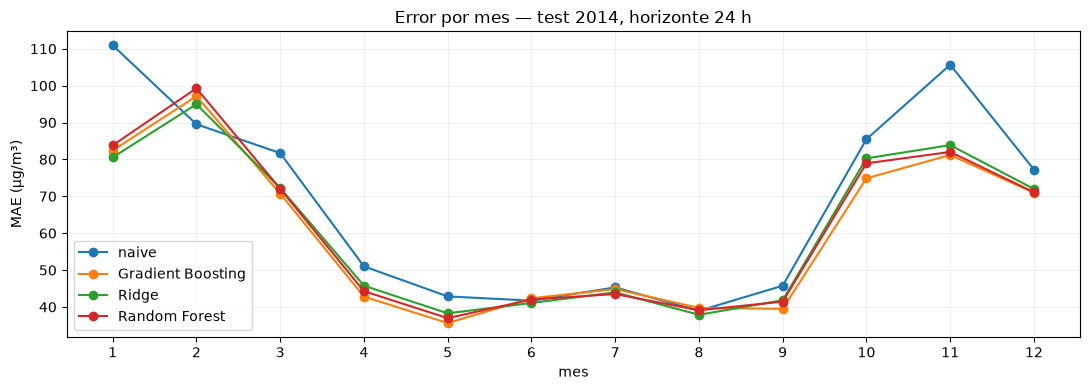

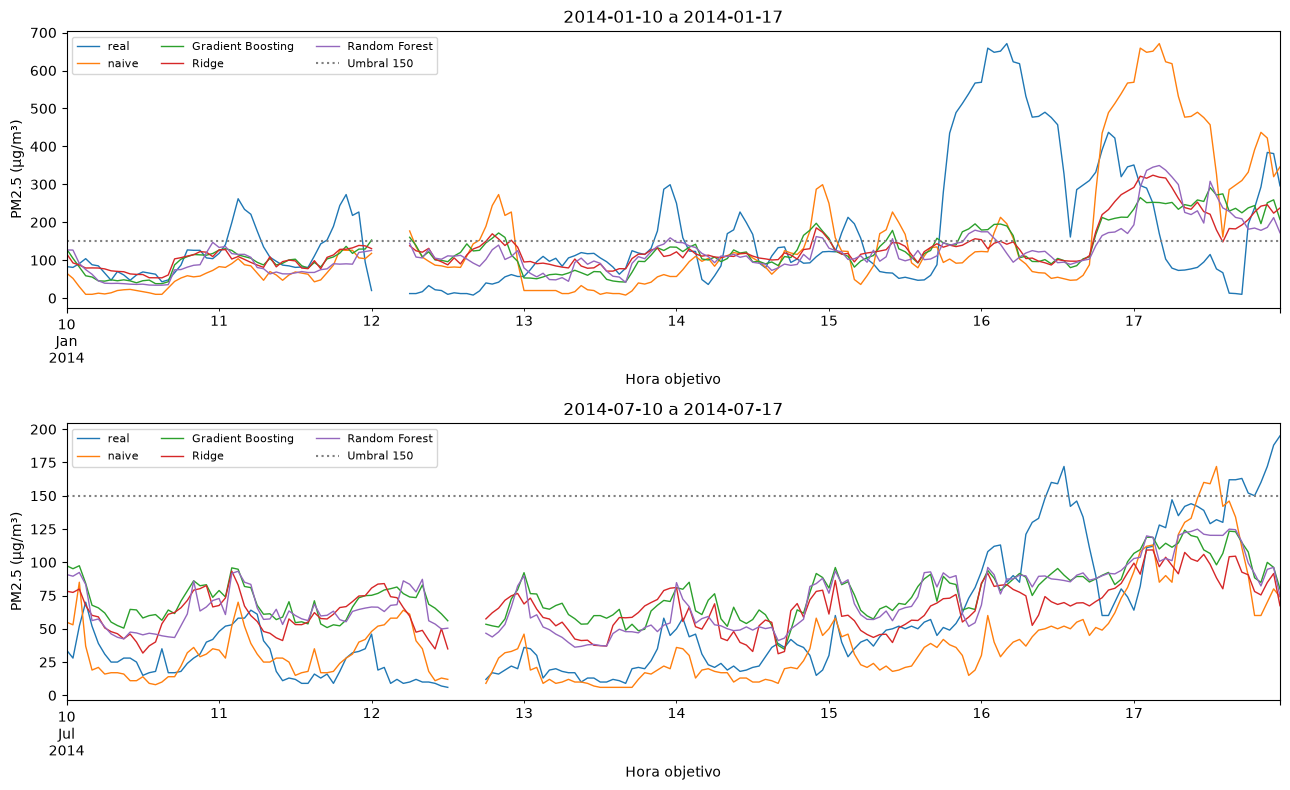

In [16]:
errores = predicciones.drop(columns='real').sub(y_test, axis=0).abs()
mae_mensual = errores.groupby(errores.index.month).mean()
mae_mensual.index.name = 'mes'
display(mae_mensual.round(2))

mae_mensual.plot(figsize=(11, 4), marker='o')
plt.ylabel('MAE (µg/m³)')
plt.title('Error por mes — test 2014, horizonte 24 h')
plt.xticks(range(1, 13))
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(13, 8))
for ax, (inicio, fin) in zip(axes, [('2014-01-10', '2014-01-17'),
                                  ('2014-07-10', '2014-07-17')]):
    predicciones.loc[inicio:fin].asfreq('h').plot(ax=ax, linewidth=1)
    ax.axhline(UMBRAL, color='grey', linestyle=':', label='Umbral 150')
    ax.set_title(f'{inicio} a {fin}')
    ax.set_ylabel('PM2.5 (µg/m³)')
    ax.set_xlabel('Hora objetivo')
    ax.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()


## 9. Resultados y límites

Se informa del modelo seleccionado en validación, aunque otro consiga mejor
resultado en test. Las métricas se calculan sin redondear; se redondean al mostrar.


In [17]:
global_ganador = metricas.loc[('global', ganador_validacion)]
alta_ganador = metricas.loc[(f'> {UMBRAL}', ganador_validacion)]
print('Elegido con 2013:', ganador_validacion)
print(f'Test: RMSE {global_ganador["RMSE"]:.2f}; MAE {global_ganador["MAE"]:.2f}')
print(f'Skill RMSE global: {global_ganador["skill_RMSE"]:.1%}')
print(f'Skill RMSE en horas > {UMBRAL}: {alta_ganador["skill_RMSE"]:.1%}')
print(f'Recall de horas altas: {alertas.loc[ganador_validacion, "recall"]:.1%}')


Elegido con 2013: Gradient Boosting
Test: RMSE 81.64; MAE 59.90
Skill RMSE global: 18.0%
Skill RMSE en horas > 150: -1.7%
Recall de horas altas: 36.0%


### Lectura de la ejecución guardada

La selección se realiza con RMSE medio en las tres rondas de 2013. El test de 2014 se informa por separado y no modifica las configuraciones.

La serie se completa para que `ForecasterRecursive` pueda generar retardos sobre un índice horario continuo. Los ejemplos afectados por imputaciones reciben peso 0 mediante `weight_func`, y los objetivos imputados se excluyen también de las métricas. Por tanto, el número de horas evaluadas puede diferir del cuaderno anterior.


- Se excluyen objetivos imputados de las métricas. En entrenamiento, los ejemplos
  con objetivo o lags imputados reciben peso cero. En predicción se permiten lags completados
  hacia delante; el resultado describe ese escenario de datos faltantes.
- No hay una marca de imputación meteorológica: la trazabilidad solo cubre PM2.5.
- Los tres modelos y persistencia se evalúan sobre las mismas horas. SARIMA histórico usa otras.
- La selección usa 2013; 2014 se reserva para informar. El análisis exploratorio previo ya vio 2014.
- Los lags son fijos y la búsqueda es pequeña. Mejor RMSE no implica mejor detección de picos.
- El lote es equivalente al paso 24 con estos lags; no generalizarlo a lags menores que 24.


In [18]:
print(f'Tiempo total: {perf_counter() - INICIO:.1f} s')


Tiempo total: 114.7 s


# 10. Nuevos modelos, contexto de PM2.5 y horizontes

Este bloque amplía la copia de `05_2`, sin modificar el original. Usa el CSV preparado
para construir variables causales específicas de cada horizonte: el CSV predictivo
24 h no sirve sin realinear para 6/12 h. Incluye LightGBM, regresión y clasificación.

Dependencia adicional: si falta LightGBM, ejecutar `%pip install lightgbm` en una
celda y reiniciar el kernel. No se instala automáticamente al ejecutar este notebook.

**Protocolo fijo:** ajuste hasta diciembre 2012; calibración de umbrales enero–abril
2013; selección mayo–diciembre 2013 con el mismo modelo fijo; ajuste final hasta
diciembre 2013; evaluación reutilizada de 2014. No se reajustan umbrales con 2014.
Todas las etiquetas de entrenamiento terminan antes del corte. Las etiquetas de
ventana exigen todas las mediciones reales disponibles; no imputamos eventos.

El presupuesto exploratorio es una tasa de falsas alarmas de 15 % entre horas
negativas. No equivale a un 85 % de precisión. Cambiarlo requiere repetir todo el
protocolo, sin escogerlo por los resultados de 2014. Se muestra el cumplimiento
fuera de calibración: un presupuesto calibrado no está garantizado en el futuro.


In [19]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import average_precision_score, precision_recall_curve, brier_score_loss
import importlib.metadata as ex_metadata

EX_INICIO = perf_counter()
EX_FPR_MAX = 0.15
EX_TAREAS = {'exacta_6h': 6, 'exacta_12h': 12, 'exacta_24h': 24, 'alguna_24h': 24}
ex_preparado_path = RAIZ / 'data/processed/beijing_data_preparado.csv'
ex_p = pd.read_csv(ex_preparado_path, index_col='datetime', parse_dates=True).sort_index().asfreq('h')
assert ex_p.index.is_unique
assert ex_p['pm2.5_imputado'].notna().all()
assert ex_p['pm2.5_imputado'].isin([True, False, 0, 1]).all()
ex_real = ex_p['pm2.5'].mask(ex_p['pm2.5_imputado'].astype(bool))
ex_y = ex_real.ffill().loc[ex_real.first_valid_index():]
ex_medida = ex_real.reindex(ex_y.index).notna()
print('CSV de los nuevos experimentos:', ex_preparado_path)
print('LightGBM:', ex_metadata.version('lightgbm'))


CSV de los nuevos experimentos: ..\data\processed\beijing_data_preparado.csv
LightGBM: 4.7.0


## 10.1 Variables conocidas en el momento del aviso

Referencia: siete lags de PM2.5 y calendario/meteorología observada al origen,
incluidas tendencias meteorológicas de 6/12/24 h.

Ampliación: medias, máximos y desviaciones de PM2.5 de 6/12/24/48 h; cambios de
3/6/12/24 h; historial de 48/72/168 h; duración de la racha alta observada al origen.
Para predecir t a horizonte h, ninguna variable observa después de t−h.

Se excluyen del entrenamiento las filas con cualquier dependencia PM2.5 imputada
del grupo ampliado, **también en los modelos de referencia**, para comparar las
mismas filas. En evaluación se permite el relleno causal del historial como en
05_2; solo las etiquetas medidas entran en las métricas. La cobertura se informa.
El clasificador usa matrices construidas por skforecast, pero se ajusta directamente
con scikit-learn/LightGBM; los regresores sí se ajustan dentro de ForecasterRecursive.


In [20]:
def ex_datos(h):
    idx = ex_y.index
    e = pd.DataFrame(index=idx)
    for nombre, v, periodo in [('hora', idx.hour, 24), ('dia', idx.dayofweek, 7), ('mes', idx.month-1, 12)]:
        e[f'cal_sen_{nombre}'] = np.sin(2*np.pi*v/periodo)
        e[f'cal_cos_{nombre}'] = np.cos(2*np.pi*v/periodo)
    met = [c for c in ex_p if c not in ['pm2.5', 'pm2.5_imputado', 'viento_cv']]
    for c in met:
        e[f'{c}_obs'] = ex_p[c].reindex(idx).astype(float).shift(h)
    for c in ['TEMP', 'PRES', 'DEWP']:
        for v in [6,12,24]:
            e[f'{c}_trend_{v}'] = ex_p[c].reindex(idx).shift(h) - ex_p[c].reindex(idx).shift(h+v)
    cols_base = list(e)
    pasado = ex_y.shift(h)
    for ventana in [6,12,24,48]:
        roll = pasado.rolling(ventana, min_periods=ventana)
        e[f'pm_media_{ventana}'] = roll.mean()
        e[f'pm_max_{ventana}'] = roll.max()
        e[f'pm_std_{ventana}'] = roll.std()
    for v in [3,6,12,24]:
        e[f'pm_cambio_{v}'] = pasado - ex_y.shift(h+v)
    for v in [48,72,168]:
        e[f'pm_hist_{v}'] = ex_y.shift(h+v)
    alta_origen = ex_real.reindex(idx).gt(UMBRAL)
    racha = alta_origen.groupby((~alta_origen).cumsum()).cumsum()
    e['pm_racha_alta'] = racha.shift(h)
    # Todas las ventanas 48 h y lags extendidos medidos; racha de valores observados.
    limpio = ex_medida.shift(h, fill_value=False).rolling(48, min_periods=48).sum().eq(48)
    for v in [48,72,168]:
        limpio &= ex_medida.shift(h+v, fill_value=False)
    e = e.loc[e.notna().all(axis=1)]
    assert e.index.equals(pd.date_range(e.index.min(), e.index.max(), freq='h'))
    ys = ex_y.loc[e.index]
    constructor = ForecasterRecursive(estimator=HistGradientBoostingRegressor(), lags=[h+v for v in [0,1,2,3,6,12,24]])
    X, _ = constructor.create_train_X_y(y=ys, exog=e)
    base_cols = [c for c in X if c.startswith('lag_')] + cols_base
    return {'y': ys, 'exog': e, 'X': X, 'base_cols': base_cols,
            'limpio': limpio.reindex(X.index).fillna(False), 'lags': list(constructor.lags)}

ex_cache = {h: ex_datos(h) for h in [6,12,24]}
EX_CANDIDATOS = {
    'HGB_referencia': ('reg', False, 'hgb'),
    'HGB_contexto': ('reg', True, 'hgb'),
    'LightGBM_contexto': ('reg', True, 'lgb'),
    'HGB_clasificador': ('clas', True, 'hgb'),
    'LightGBM_clasificador': ('clas', True, 'lgb'),
}

def ex_objetivo(tarea, datos):
    r = ex_real.reindex(datos['X'].index)
    if tarea == 'alguna_24h':
        # Índice = final de la ventana. Origen = índice - 24 h.
        observado = ex_real.rolling(24, min_periods=24)
        r = observado.max().where(observado.count().eq(24)).reindex(datos['X'].index)
    return r

def ex_estimador(tipo, algoritmo):
    if algoritmo == 'lgb':
        cls = LGBMClassifier if tipo == 'clas' else LGBMRegressor
        return cls(n_estimators=200, num_leaves=15, learning_rate=.05,
                   min_child_samples=30, reg_lambda=1, n_jobs=2, random_state=SEMILLA, verbosity=-1)
    cls = HistGradientBoostingClassifier if tipo == 'clas' else HistGradientBoostingRegressor
    return cls(max_leaf_nodes=15, max_iter=200, learning_rate=.05,
               min_samples_leaf=30, early_stopping=False, random_state=SEMILLA)

def ex_fit(tarea, nombre, corte):
    h = EX_TAREAS[tarea]; d = ex_cache[h]
    tipo, ampliado, algoritmo = EX_CANDIDATOS[nombre]
    objetivo = ex_objetivo(tarea, d)
    modelo = ex_estimador(tipo, algoritmo)
    columnas = list(d['X']) if ampliado else d['base_cols']
    if tipo == 'reg':
        assert tarea != 'alguna_24h'
        def pesos(index):
            valido = d['limpio'].reindex(index).fillna(False) & ex_real.reindex(index).notna()
            return valido.astype(float).to_numpy()
        columnas_exog = list(d['exog']) if ampliado else [c for c in d['base_cols'] if not c.startswith('lag_')]
        f = ForecasterRecursive(estimator=modelo, lags=d['lags'], weight_func=pesos)
        with threadpool_limits(limits=2):
            f.fit(y=d['y'].loc[:corte], exog=d['exog'].loc[:corte, columnas_exog])
        return (f, columnas, tipo)
    train = (d['X'].index <= pd.Timestamp(corte)) & d['limpio'] & objetivo.notna()
    with threadpool_limits(limits=2):
        modelo.fit(d['X'].loc[train, columnas].to_numpy(), objetivo.loc[train].gt(UMBRAL).astype(int))
    return (modelo, columnas, tipo)

def ex_predict(ajuste, datos, idx):
    m, cols, tipo = ajuste
    with threadpool_limits(limits=2):
        X = datos['X'].loc[idx, cols].to_numpy()
        p = m.predict_proba(X)[:,1] if tipo == 'clas' else m.estimator.predict(X).clip(min=0)
    return pd.Series(p, index=idx)

def ex_metricas(real_obj, score, umbral, tipo):
    ok = real_obj.notna() & score.notna(); yt, p = real_obj[ok], score[ok]
    z, a = yt.gt(UMBRAL), p.gt(umbral)
    tp, fp, fn, tn = [(int(v.sum())) for v in [z&a, ~z&a, z&~a, ~z&~a]]
    return {'n':len(yt), 'altas':int(z.sum()), 'recall':tp/(tp+fn) if tp+fn else 0,
            'precision':tp/(tp+fp) if tp+fp else 0, 'FPR':fp/(fp+tn) if fp+tn else 0,
            'FP':fp, 'FN':fn, 'avisos':tp+fp, 'AP':average_precision_score(z,p),
            'RMSE':np.sqrt(mean_squared_error(yt,p)) if tipo=='reg' else np.nan,
            'Brier':brier_score_loss(z,p) if tipo=='clas' else np.nan}

def ex_umbral(real_obj, score, tipo):
    # Incluye máximo: siempre es posible no emitir avisos si no hay señal útil.
    rejilla = np.unique(np.quantile(score.loc[real_obj.notna()], np.linspace(0,1,201)))
    tabla = pd.DataFrame([{'umbral':float(t), **ex_metricas(real_obj,score,t,tipo)} for t in rejilla])
    factibles = tabla.loc[tabla.FPR <= EX_FPR_MAX]
    mejor = factibles.sort_values(['recall','FPR','umbral'], ascending=[False,True,False]).iloc[0]
    return float(mejor.umbral), tabla


## 10.2 Calibración y selección sin usar 2014

Se compara cada candidato con persistencia al mismo presupuesto nominal de falsas
alarmas. Para «alguna superación en 24 h» se añade como referencia el máximo de
las 24 h previas, conocido al origen. Los clasificadores producen probabilidades
sin calibración probabilística adicional; se informa Brier y no se interpretan
como probabilidades perfectamente calibradas.

La tarea de ventana mide cualquier superación, incluidos episodios ya activos al
origen. No equivale a predecir el inicio de un episodio nuevo. Sus ventanas se
solapan: las filas no son eventos independientes y no se comparan directamente
sus métricas con las del horizonte exacto.


exacta_6h HGB_referencia 1.7 s
exacta_6h HGB_contexto 4.0 s
exacta_6h LightGBM_contexto 1.0 s
exacta_6h HGB_clasificador 1.1 s
exacta_6h LightGBM_clasificador 0.7 s
exacta_12h HGB_referencia 1.4 s
exacta_12h HGB_contexto 3.7 s
exacta_12h LightGBM_contexto 0.9 s
exacta_12h HGB_clasificador 1.0 s
exacta_12h LightGBM_clasificador 0.7 s
exacta_24h HGB_referencia 1.5 s
exacta_24h HGB_contexto 4.2 s
exacta_24h LightGBM_contexto 0.6 s
exacta_24h HGB_clasificador 0.7 s
exacta_24h LightGBM_clasificador 0.5 s
alguna_24h HGB_clasificador 0.8 s
alguna_24h LightGBM_clasificador 0.5 s


,tarea,modelo,tipo,umbral,n,altas,recall,precision,FPR,FP,FN,avisos,AP,RMSE,Brier,cumple_presupuesto
0,exacta_6h,HGB_referencia,reg,122.422,5808,994,0.801,0.562,0.129,621,198,1417,0.727,48.733,NaN,True
1,exacta_6h,HGB_contexto,reg,128.615,5808,994,0.759,0.596,0.106,512,240,1266,0.725,49.085,NaN,True
2,exacta_6h,LightGBM_contexto,reg,131.061,5808,994,0.737,0.612,0.097,465,261,1198,0.722,49.179,NaN,True
3,exacta_6h,HGB_clasificador,clas,0.281,5808,994,0.798,0.554,0.133,638,201,1431,0.702,NaN,0.083,True
4,exacta_6h,LightGBM_clasificador,clas,0.292,5808,994,0.790,0.568,0.124,598,209,1383,0.711,NaN,0.082,True
5,exacta_6h,persistencia,reg,128.000,5808,994,0.738,0.552,0.124,596,260,1330,0.628,59.135,NaN,True
6,exacta_12h,HGB_referencia,reg,137.086,5802,994,0.512,0.527,0.095,456,485,965,0.544,62.477,NaN,True
7,exacta_12h,HGB_contexto,reg,144.303,5802,994,0.480,0.594,0.068,326,517,803,0.550,62.432,NaN,True
8,exacta_12h,LightGBM_contexto,reg,146.825,5802,994,0.458,0.603,0.062,299,539,754,0.545,62.601,NaN,True
9,exacta_12h,HGB_clasificador,clas,0.454,5802,994,0.449,0.533,0.081,390,548,836,0.502,NaN,0.110,True


,tarea,modelo,umbral,recall,precision,FPR,estado
0,exacta_6h,HGB_referencia,122.422203,0.800805,0.561750,0.128999,Cumple en selección; no garantizado fuera de m...
1,exacta_12h,HGB_referencia,137.085854,0.512072,0.527461,0.094842,Cumple en selección; no garantizado fuera de m...
2,exacta_24h,HGB_referencia,139.324127,0.342052,0.479549,0.076939,Cumple en selección; no garantizado fuera de m...
3,alguna_24h,maximo_previo,296.000000,0.173166,0.742806,0.047906,Cumple en selección; no garantizado fuera de m...


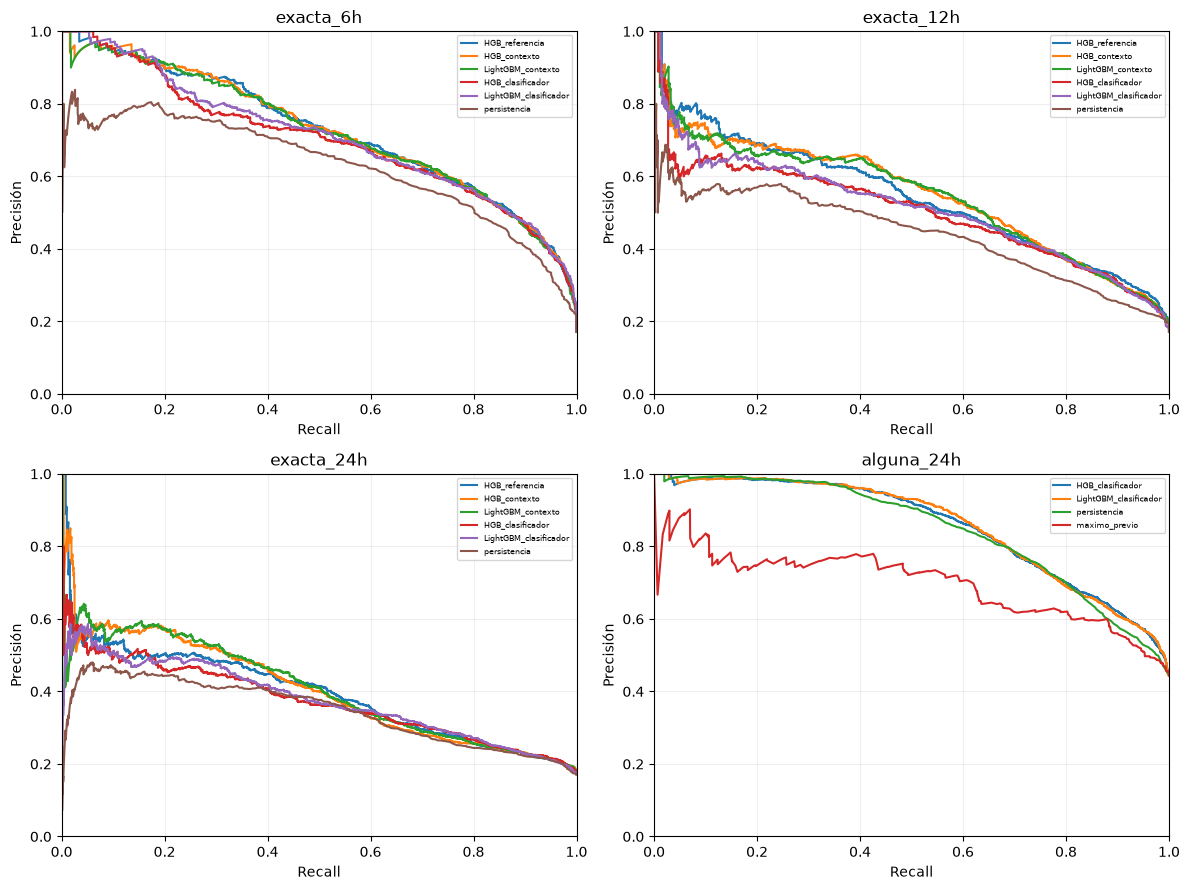

In [21]:
ex_filas, ex_pred, ex_curvas, ex_elegidas, ex_ajustes = [], [], [], [], {}
for tarea, h in EX_TAREAS.items():
    d = ex_cache[h]; obj = ex_objetivo(tarea,d)
    inicio_cal = pd.Timestamp('2013-01-01')+pd.Timedelta(hours=h)
    inicio_sel = pd.Timestamp('2013-05-01')+pd.Timedelta(hours=h)
    idx = d['X'].loc[inicio_cal:'2013-12-31 23:00'].index
    frame = pd.DataFrame({'real':obj.loc[idx]}, index=idx)
    frame['persistencia'] = ex_y.shift(h).reindex(idx)
    nombres = [n for n,v in EX_CANDIDATOS.items() if tarea!='alguna_24h' or v[0]=='clas']
    for nombre in nombres:
        t0=perf_counter(); ajuste=ex_fit(tarea,nombre,'2012-12-31 23:00')
        ex_ajustes[(tarea,nombre)] = ajuste
        frame[nombre]=ex_predict(ajuste,d,idx)
        print(tarea, nombre, f'{perf_counter()-t0:.1f} s')
    candidatos_tipos = {n:EX_CANDIDATOS[n][0] for n in nombres}
    candidatos_tipos['persistencia']='reg'
    if tarea=='alguna_24h':
        frame['maximo_previo'] = ex_y.rolling(24).max().shift(24).reindex(idx)
        candidatos_tipos['maximo_previo']='score'
        candidatos_tipos['persistencia']='score'
    cal=frame.loc[:'2013-04-30 23:00']; sel=frame.loc[inicio_sel:]
    filas_tarea=[]
    for nombre,tipo in candidatos_tipos.items():
        u, curva=ex_umbral(cal.real,cal[nombre],tipo)
        ex_curvas.append(curva.assign(tarea=tarea,modelo=nombre))
        fila={'tarea':tarea,'modelo':nombre,'tipo':tipo,'umbral':u,
              **ex_metricas(sel.real,sel[nombre],u,tipo)}
        fila['cumple_presupuesto']=fila['FPR']<=EX_FPR_MAX
        filas_tarea.append(fila)
    tabla=pd.DataFrame(filas_tarea)
    factibles=tabla.loc[tabla.cumple_presupuesto]
    if len(factibles):
        elegida=factibles.sort_values(['recall','FPR'],ascending=[False,True]).iloc[0]
        estado='Cumple en selección; no garantizado fuera de muestra'
    else:
        elegida=tabla.sort_values(['FPR','recall'],ascending=[True,False]).iloc[0]
        estado='Ninguno cumple: referencia exploratoria de menor FPR'
    ex_elegidas.append({**elegida.to_dict(),'estado':estado})
    ex_filas.extend(filas_tarea)
    ex_pred.append(frame.assign(tarea=tarea))
ex_seleccion=pd.DataFrame(ex_filas)
ex_decisiones=pd.DataFrame(ex_elegidas)
ex_pred_2013=pd.concat(ex_pred)
ex_curvas=pd.concat(ex_curvas,ignore_index=True)
display(ex_seleccion.round(3))
display(ex_decisiones[['tarea','modelo','umbral','recall','precision','FPR','estado']])

fig, axes = plt.subplots(2,2,figsize=(12,9))
for ax,(tarea,h) in zip(axes.flat,EX_TAREAS.items()):
    f=ex_pred_2013.loc[ex_pred_2013.tarea.eq(tarea)].loc[pd.Timestamp('2013-05-01')+pd.Timedelta(hours=h):].dropna(subset=['real'])
    for nombre in ex_seleccion.loc[ex_seleccion.tarea.eq(tarea),'modelo']:
        pr,rc,_=precision_recall_curve(f.real.gt(UMBRAL),f[nombre])
        ax.plot(rc,pr,label=nombre)
    ax.set(title=tarea,xlabel='Recall',ylabel='Precisión',xlim=(0,1),ylim=(0,1))
    ax.legend(fontsize=6);ax.grid(alpha=.2)
plt.tight_layout();plt.show()


## 10.3 Evaluación reutilizada de 2014 y anticipación

Se reentrenan el ganador de cada tarea y la referencia HGB original de variables
para las tareas exactas. Se mantienen los umbrales calibrados; se informa si el
presupuesto se incumple. La columna «FPR» es la tasa real observada, no una igualdad
garantizada entre modelos. No elegir otra política mirando estos resultados.

Para las tareas exactas, episodio = bloque de mediciones consecutivas > 150 con
transición previa medida desde ≤ 150. Se cuenta anticipación solo si un aviso
para una hora del episodio se emitió antes de su inicio. Huecos no confirman inicios.
Las ventanas de 24 h tienen otra semántica y no entran en esta tabla por episodios.


In [22]:
ex_test_filas, ex_test_frames, ex_episodios = [], [], []
for decision in ex_decisiones.to_dict('records'):
    tarea=decision['tarea'];h=EX_TAREAS[tarea];d=ex_cache[h]
    idx=d['X'].loc[pd.Timestamp('2014-01-01')+pd.Timedelta(hours=h):'2014-12-31 23:00'].index
    f=pd.DataFrame({'real':ex_objetivo(tarea,d).loc[idx]},index=idx)
    f['persistencia']=ex_y.shift(h).reindex(idx)
    nombres=list(dict.fromkeys([decision['modelo'],'persistencia']+(['HGB_referencia'] if tarea!='alguna_24h' else ['maximo_previo'])))
    for nombre in nombres:
        if nombre=='maximo_previo':
            f[nombre]=ex_y.rolling(24).max().shift(24).reindex(idx)
        elif nombre!='persistencia':
            ajuste=ex_fit(tarea,nombre,'2013-12-31 23:00')
            f[nombre]=ex_predict(ajuste,d,idx)
        fila=ex_seleccion.loc[ex_seleccion.tarea.eq(tarea)&ex_seleccion.modelo.eq(nombre)].iloc[0]
        resultado={'tarea':tarea,'modelo':nombre,'elegido':nombre==decision['modelo'],
                   'umbral':float(fila.umbral),**ex_metricas(f.real,f[nombre],fila.umbral,fila.tipo)}
        resultado['cumple_presupuesto']=resultado['FPR']<=EX_FPR_MAX
        ex_test_filas.append(resultado)
        if tarea!='alguna_24h':
            altas=ex_real.gt(UMBRAL);grupos=altas.ne(altas.shift(fill_value=False)).cumsum()
            detalles=[]
            for _,tramo in ex_real.loc[altas].groupby(grupos.loc[altas]):
                comienzo,fin=tramo.index.min(),tramo.index.max()
                anterior=ex_real.get(comienzo-pd.Timedelta(hours=1),np.nan)
                if comienzo not in idx or pd.isna(anterior) or anterior>UMBRAL or comienzo+pd.Timedelta(hours=h-1)>idx.max():
                    continue
                scores=f[nombre].loc[comienzo:fin]
                emisiones=scores.index[scores>fila.umbral]-pd.Timedelta(hours=h)
                previas=emisiones[emisiones<comienzo]
                detalles.append({'inicio':comienzo,'anticipado':bool(len(previas)),
                                 'anticipacion_h':(comienzo-previas.min()).total_seconds()/3600 if len(previas) else np.nan})
            detalle=pd.DataFrame(detalles)
            ex_episodios.append({'tarea':tarea,'modelo':nombre,'episodios':len(detalle),
                                'recall_anticipado':detalle.anticipado.mean(),
                                'mediana_anticipacion_solo_aciertos':detalle.anticipacion_h.median()})
    ex_test_frames.append(f.assign(tarea=tarea))
ex_test=pd.DataFrame(ex_test_filas)
ex_pred_test=pd.concat(ex_test_frames)
ex_episodios=pd.DataFrame(ex_episodios)
display(ex_test.round(3))
display(ex_episodios.round(3))


,tarea,modelo,elegido,umbral,n,altas,recall,precision,FPR,FP,FN,avisos,AP,RMSE,Brier,cumple_presupuesto
0,exacta_6h,HGB_referencia,True,122.422,8655,1737,0.856,0.619,0.132,914,250,2401,0.801,51.850,NaN,True
1,exacta_6h,persistencia,False,128.000,8655,1737,0.785,0.607,0.128,883,373,2247,0.732,61.681,NaN,True
2,exacta_12h,HGB_referencia,True,137.086,8649,1737,0.645,0.631,0.095,655,617,1775,0.676,66.696,NaN,True
3,exacta_12h,persistencia,False,162.000,8649,1737,0.512,0.585,0.091,630,848,1519,0.583,82.817,NaN,True
4,exacta_24h,HGB_referencia,True,139.324,8637,1737,0.413,0.533,0.091,628,1020,1345,0.484,82.013,NaN,True
5,exacta_24h,persistencia,False,210.810,8637,1737,0.294,0.540,0.063,436,1226,947,0.440,99.624,NaN,True
6,alguna_24h,maximo_previo,True,296.000,7951,3786,0.208,0.770,0.056,235,3000,1021,0.684,NaN,NaN,True
7,alguna_24h,persistencia,False,85.000,7951,3786,0.740,0.809,0.158,659,986,3459,0.877,NaN,NaN,False


,tarea,modelo,episodios,recall_anticipado,mediana_anticipacion_solo_aciertos
0,exacta_6h,HGB_referencia,168,0.750,6.0
1,exacta_6h,persistencia,168,0.595,6.0
2,exacta_12h,HGB_referencia,168,0.464,11.5
3,exacta_12h,persistencia,168,0.226,12.0
4,exacta_24h,HGB_referencia,168,0.315,22.0
5,exacta_24h,persistencia,168,0.161,23.0


## 10.4 Comprobaciones y límites

Se verifica la equivalencia del lote con skforecast.predict en cada horizonte,
la causalidad de las variables y la definición de las ventanas de evento.
Las tablas y gráficas muestran los resultados directamente en este notebook.

La comparación que atribuye valor a las nuevas variables es HGB_referencia frente
a HGB_contexto, en las mismas filas. El LightGBM adicional no garantiza mejorar.
No se comparan RMSE de probabilidades con RMSE de concentraciones, ni se presenta
6 h como sustituto equivalente de 24 h. La etiqueta «alguna_24h» incluye continuidad
de episodios: para nuevos inicios habría que definir y validar otra etiqueta.

Estos datos ya fueron explorados: los resultados de 2014 son evaluación reutilizada.
Las probabilidades no tienen calibración adicional; cambiar de periodo o reentrenar
puede cambiar la tasa de falsas alarmas. No se ha entrenado una política operativa
con un coste de alertas definido por usuarios reales.

Fuentes: [ventanas en skforecast](https://skforecast.org/latest/user_guides/window-features-and-custom-features.html),
[clasificación y umbral](https://scikit-learn.org/stable/modules/classification_threshold.html),
[LightGBM](https://lightgbm.readthedocs.io/en/stable/Python-API.html).


In [23]:
for h in [6,12,24]:
    tarea=f'exacta_{h}h';d=ex_cache[h]
    modelo,cols,_=ex_ajustes[(tarea,'HGB_contexto')]
    objetivos=d['X'].loc['2013-06-01':'2013-06-02'].index[[0,-1]]
    for objetivo in objetivos:
        origen=objetivo-pd.Timedelta(hours=h)
        with threadpool_limits(limits=2):
            original=modelo.predict(steps=h,last_window=d['y'].loc[:origen].tail(max(d['lags'])),
                                    exog=d['exog'].loc[origen+pd.Timedelta(hours=1):objetivo]).iloc[-1]
        lote=ex_predict((modelo,cols,'reg'),d,pd.DatetimeIndex([objetivo])).iloc[0]
        np.testing.assert_allclose(lote,max(0,original),rtol=1e-9,atol=1e-8)
    t=d['X'].index[500]
    assert d['exog'].loc[t,'pm_media_24'] == ex_y.loc[t-pd.Timedelta(hours=h+23):t-pd.Timedelta(hours=h)].mean() or np.isclose(d['exog'].loc[t,'pm_media_24'],ex_y.loc[t-pd.Timedelta(hours=h+23):t-pd.Timedelta(hours=h)].mean())
    assert d['X'].loc[t,f'lag_{h}'] == ex_y.loc[t-pd.Timedelta(hours=h)]
ex_t=ex_cache[24]['X'].index[500]
ex_ventana=ex_real.loc[ex_t-pd.Timedelta(hours=23):ex_t]
ex_etiqueta=ex_objetivo('alguna_24h',ex_cache[24]).loc[ex_t]
assert (pd.isna(ex_etiqueta) and ex_ventana.isna().any()) or ex_etiqueta==ex_ventana.max()
print('Comprobaciones de equivalencia, causalidad y etiqueta superadas')

print(f'Tiempo del bloque nuevo: {perf_counter()-EX_INICIO:.1f} s')


Comprobaciones de equivalencia, causalidad y etiqueta superadas
Tiempo del bloque nuevo: 46.8 s
